In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import ast # For converting string representations of lists back to lists
from collections import Counter
from pathlib import Path
from wordcloud import WordCloud

# Set plotting style and parameters for better aesthetics
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

print("─" * 80)
print("▶ [STEP 1] Loading the final, clean dataset...")
print("─" * 80)

# Define the path to your final dataset
DATA_PATH = Path("D:/preprocessed_data/preprocessed_data/MM-Food-Cleaned-Final.csv")

if not DATA_PATH.exists():
    print(f"ERROR: Dataset file not found at '{DATA_PATH}'. Please ensure the path is correct.")
else:
    df = pd.read_csv(DATA_PATH)
    print(f"Successfully loaded the clean dataset with {len(df)} rows and {df.shape[1]} columns.")
    
    # Convert string representation of list back to actual list for analysis
    df['ingredients'] = df['ingredients'].apply(ast.literal_eval)
    # Convert date column to datetime objects for time-series analysis
    df['submission_date'] = pd.to_datetime(df['submission_date'])

    print("\nDataset Information:")
    df.info()
    
    print("\nFirst 5 rows of the clean dataset:")
    from IPython.display import display
    display(df.head())

────────────────────────────────────────────────────────────────────────────────
▶ [STEP 1] Loading the final, clean dataset...
────────────────────────────────────────────────────────────────────────────────
Successfully loaded the clean dataset with 10996 rows and 17 columns.

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10996 entries, 0 to 10995
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   dish_name                10996 non-null  object        
 1   image_filepath           10996 non-null  object        
 2   submission_date          10996 non-null  datetime64[ns]
 3   food_type                10996 non-null  object        
 4   food_type.1              10996 non-null  object        
 5   cooking_method           10888 non-null  object        
 6   ingredients              10996 non-null  object        
 7   total_grams              10996 non-n

,dish_name,image_filepath,submission_date,food_type,food_type.1,cooking_method,ingredients,total_grams,is_duplicate_image,calories_kcal,fat_g,protein_g,carbohydrate_g,calories_kcal_per_100g,fat_g_per_100g,protein_g_per_100g,carbohydrate_g_per_100g
0,spicy crab,preprocessed_data\images_processed\0a0c19eb67a...,2025-07-05,Restaurant food,restaurant food,stir-fried,"[crab, sauce, spices, vegetables]",450.0,False,500,20.0,40.0,10.0,111.111111,4.444444,8.888889,2.222222
1,steamed snails,preprocessed_data\images_processed\066b7ba6197...,2025-07-01,Homemade food,homemade food,steamed,"[dipping sauce, garlic, herbs, snails]",350.0,False,200,5.0,30.0,10.0,57.142857,1.428571,8.571429,2.857143
2,chicken stirfry,preprocessed_data\images_processed\fecd381a783...,2025-07-18,Homemade food,homemade food,stir-frying,"[bell peppers, chicken, onions, soy sauce]",450.0,False,450,20.0,30.0,25.0,100.000000,4.444444,6.666667,5.555556
3,grilled salmon,preprocessed_data\images_processed\01e3ca00199...,2025-07-19,Restaurant food,restaurant food,Grilling,"[butter sauce, herbs, salmon]",250.0,False,350,20.0,30.0,5.0,140.000000,8.000000,12.000000,2.000000
4,braised pork belly,preprocessed_data\images_processed\34256ac8f85...,2025-07-04,Restaurant food,restaurant food,Braised,"[Green Onion, Pork Belly, Rice, Soy Sauce]",350.0,False,600,30.0,25.0,50.0,171.428571,8.571429,7.142857,14.285714


────────────────────────────────────────────────────────────────────────────────
▶ [STEP 2] Generating High-Level Statistical Overview...
────────────────────────────────────────────────────────────────────────────────

Summary statistics for key numerical columns:


,total_grams,calories_kcal,fat_g,protein_g,carbohydrate_g
count,10996.00,10996.00,10996.00,10996.00,10996.00
mean,363.93,416.26,17.79,21.58,41.13
std,179.83,256.20,15.00,18.07,29.39
min,0.00,0.00,0.00,0.00,0.00
25%,250.00,250.00,10.00,6.00,20.00
50%,350.00,350.00,15.00,20.00,36.00
75%,450.00,600.00,22.00,30.00,60.00
max,5000.00,3500.00,250.00,250.00,400.00



Analysis of Categorical Features:


C:\Users\Neelanjan Dutta\AppData\Local\Temp\ipykernel_24740\3885089582.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['food_type'], order=df['food_type'].value_counts().index, palette='viridis')


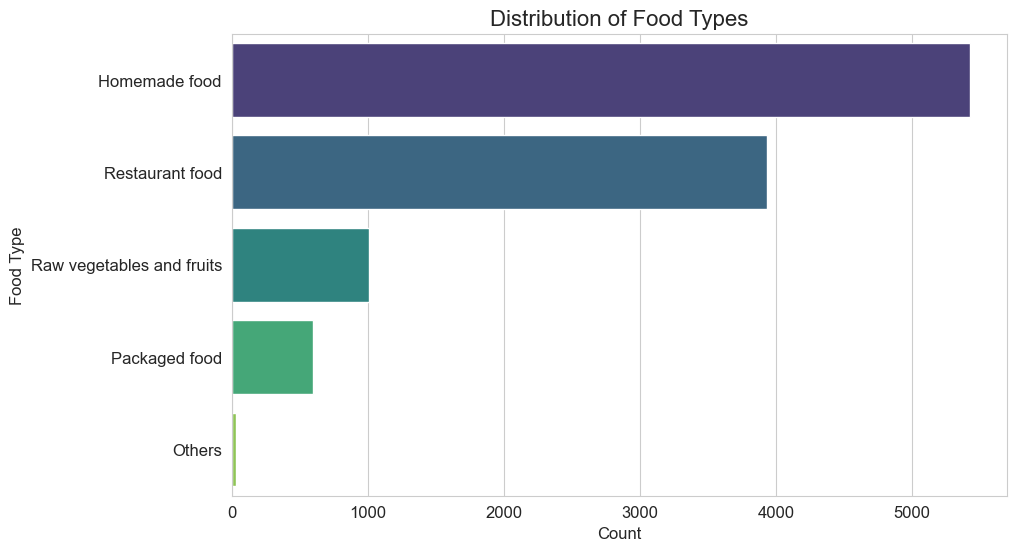

C:\Users\Neelanjan Dutta\AppData\Local\Temp\ipykernel_24740\3885089582.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['cooking_method'], order=top_10_cooking.index, palette='plasma')


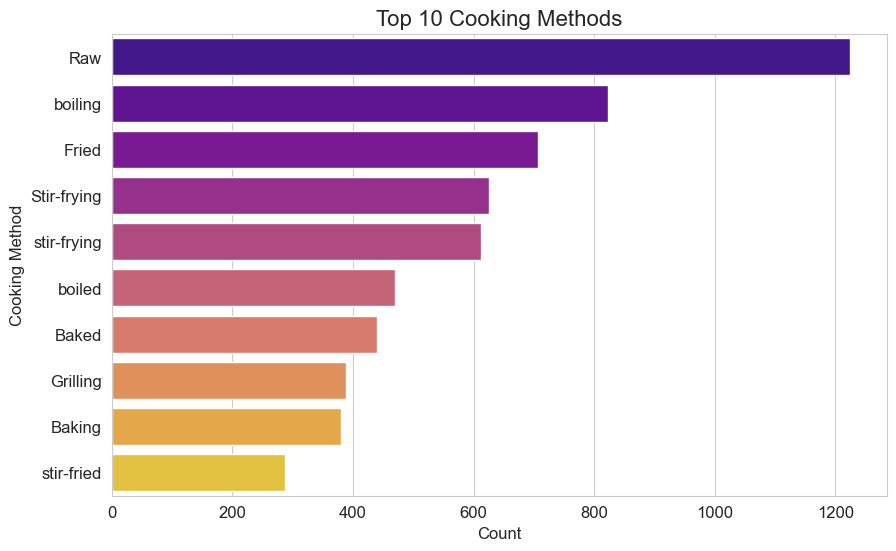

In [2]:
print("─" * 80)
print("▶ [STEP 2] Generating High-Level Statistical Overview...")
print("─" * 80)

# --- Numerical Summary ---
print("\nSummary statistics for key numerical columns:")
numerical_cols = ['total_grams', 'calories_kcal', 'fat_g', 'protein_g', 'carbohydrate_g']
from IPython.display import display
display(df[numerical_cols].describe().round(2))

# --- Categorical Analysis ---
print("\nAnalysis of Categorical Features:")

# Plot for 'food_type'
plt.figure(figsize=(10, 6))
sns.countplot(y=df['food_type'], order=df['food_type'].value_counts().index, palette='viridis')
plt.title('Distribution of Food Types', fontsize=16)
plt.xlabel('Count')
plt.ylabel('Food Type')
plt.show()

# Plot for 'cooking_method'
plt.figure(figsize=(10, 6))
top_10_cooking = df['cooking_method'].value_counts().nlargest(10)
sns.countplot(y=df['cooking_method'], order=top_10_cooking.index, palette='plasma')
plt.title('Top 10 Cooking Methods', fontsize=16)
plt.xlabel('Count')
plt.ylabel('Cooking Method')
plt.show()

────────────────────────────────────────────────────────────────────────────────
▶ [STEP 3] Analyzing Data Submissions Over Time...
────────────────────────────────────────────────────────────────────────────────


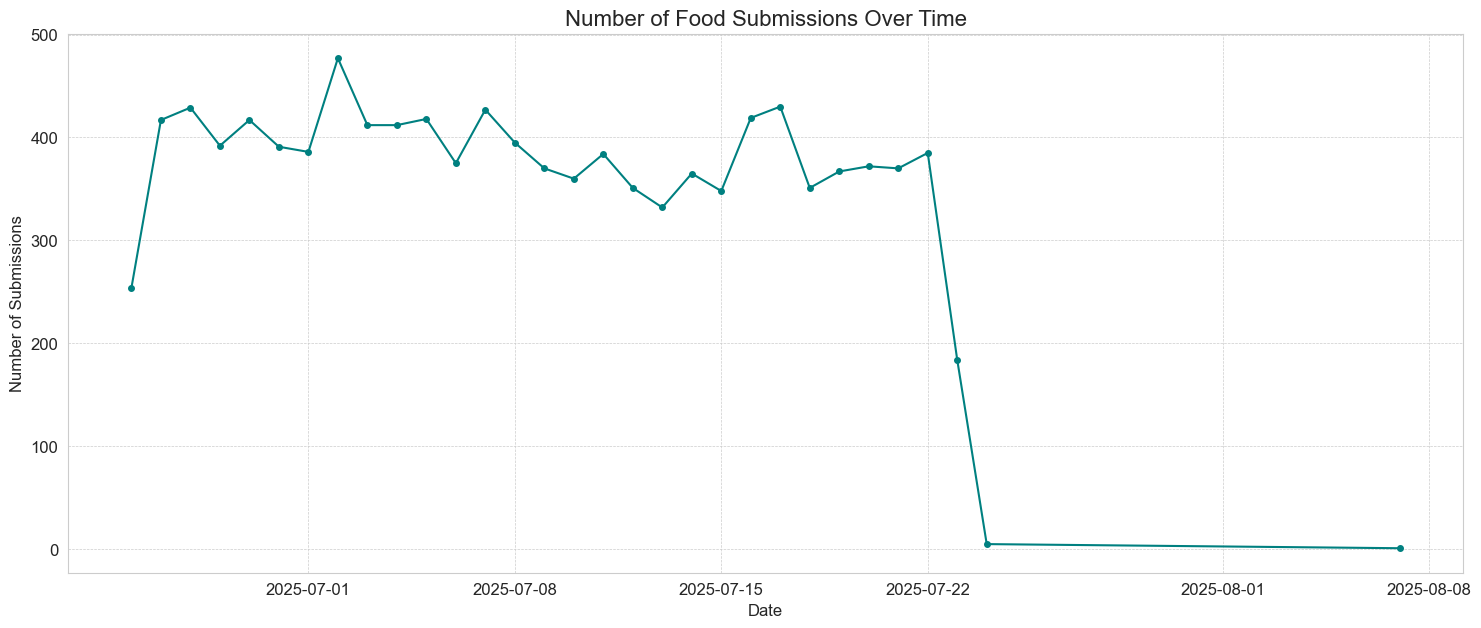

In [3]:
print("─" * 80)
print("▶ [STEP 3] Analyzing Data Submissions Over Time...")
print("─" * 80)

# Group data by date and count the number of submissions
submissions_by_day = df.groupby(df['submission_date'].dt.date).size()

plt.figure(figsize=(18, 7))
submissions_by_day.plot(kind='line', marker='o', linestyle='-', markersize=4, color='teal')
plt.title('Number of Food Submissions Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Submissions', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

────────────────────────────────────────────────────────────────────────────────
▶ [STEP 4] Deep Dive into Nutrient Profiles...
────────────────────────────────────────────────────────────────────────────────
Cleaned up infinite values that resulted from division by zero.


--- Distribution of Standardized Nutrients (per 100g) ---


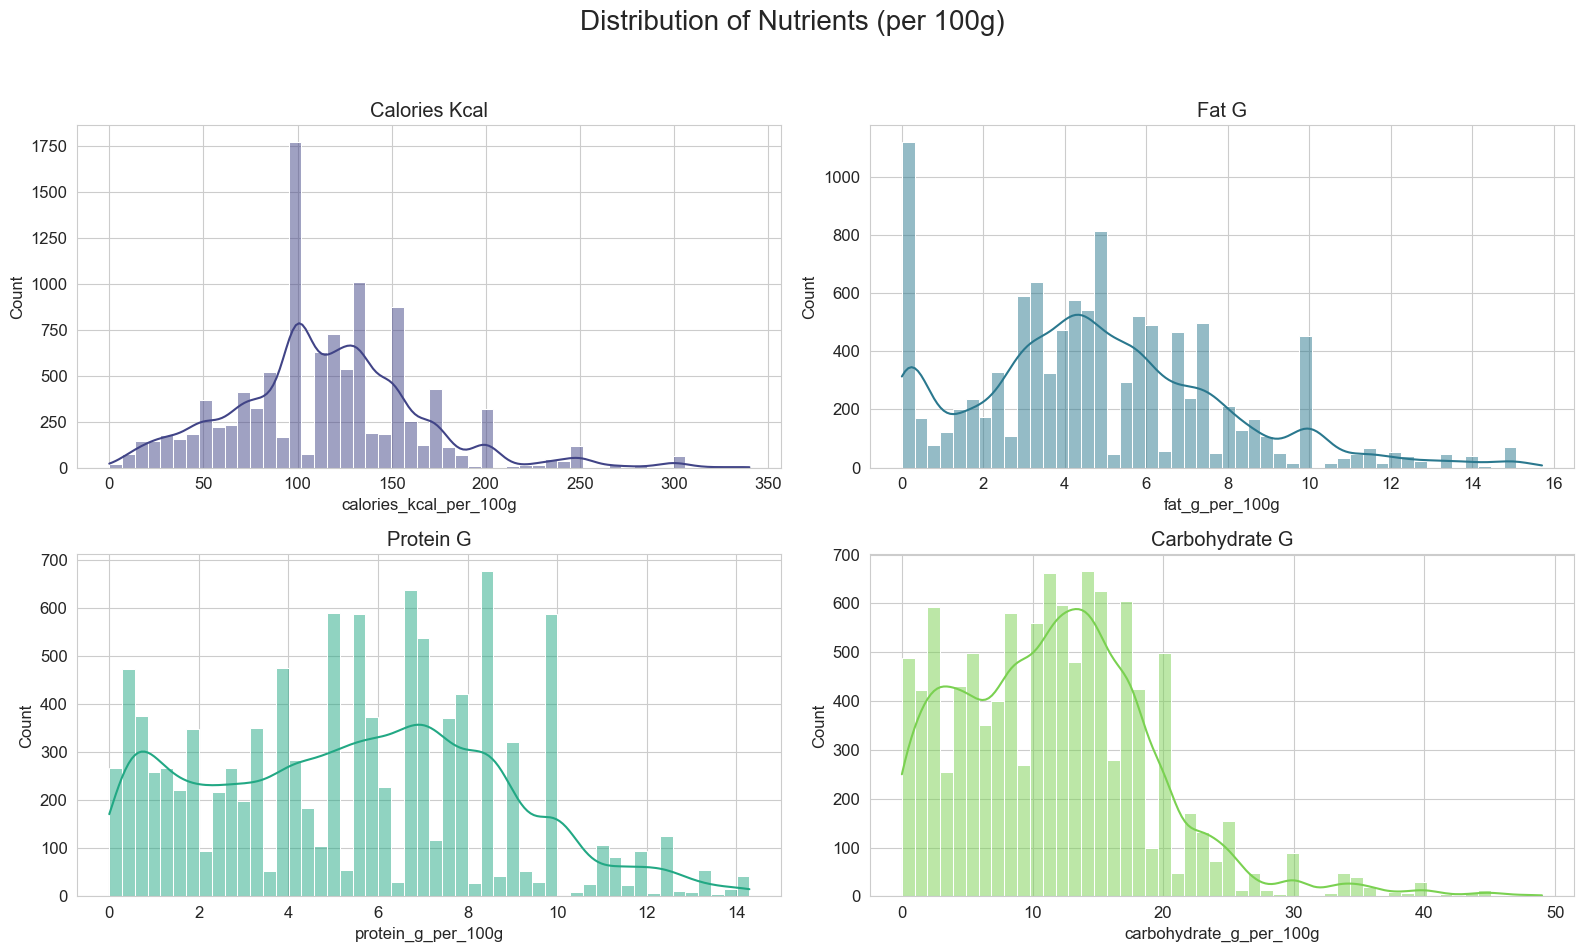


--- Nutrient Correlation Heatmap (per 100g) ---


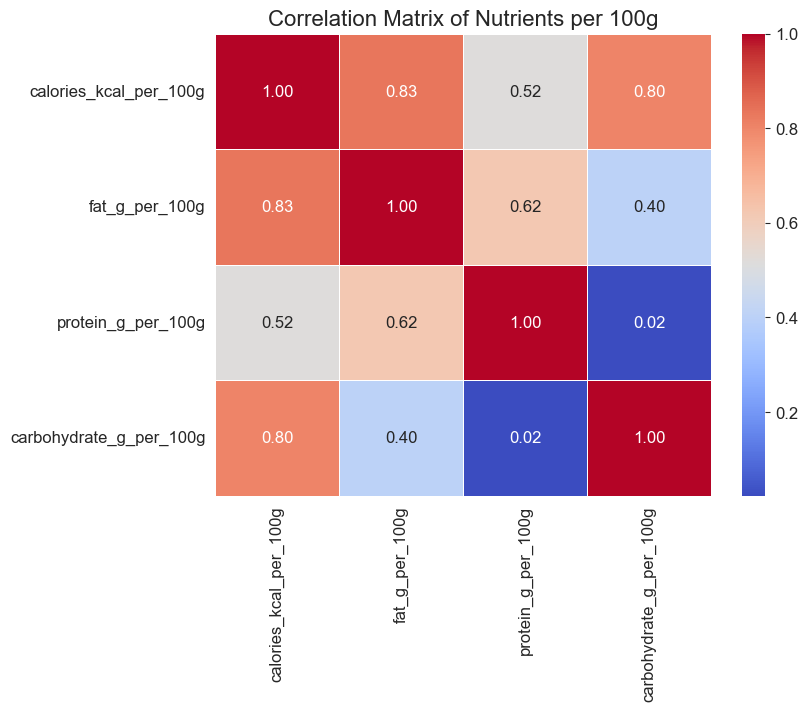


--- Comparing Nutrient Profiles Across Different Food Types ---


C:\Users\Neelanjan Dutta\AppData\Local\Temp\ipykernel_24740\2867242605.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='food_type', data=df_capped, ax=axes[i], palette='Set2')
C:\Users\Neelanjan Dutta\AppData\Local\Temp\ipykernel_24740\2867242605.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='food_type', data=df_capped, ax=axes[i], palette='Set2')
C:\Users\Neelanjan Dutta\AppData\Local\Temp\ipykernel_24740\2867242605.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='food_type', data=df_capped, ax=ax

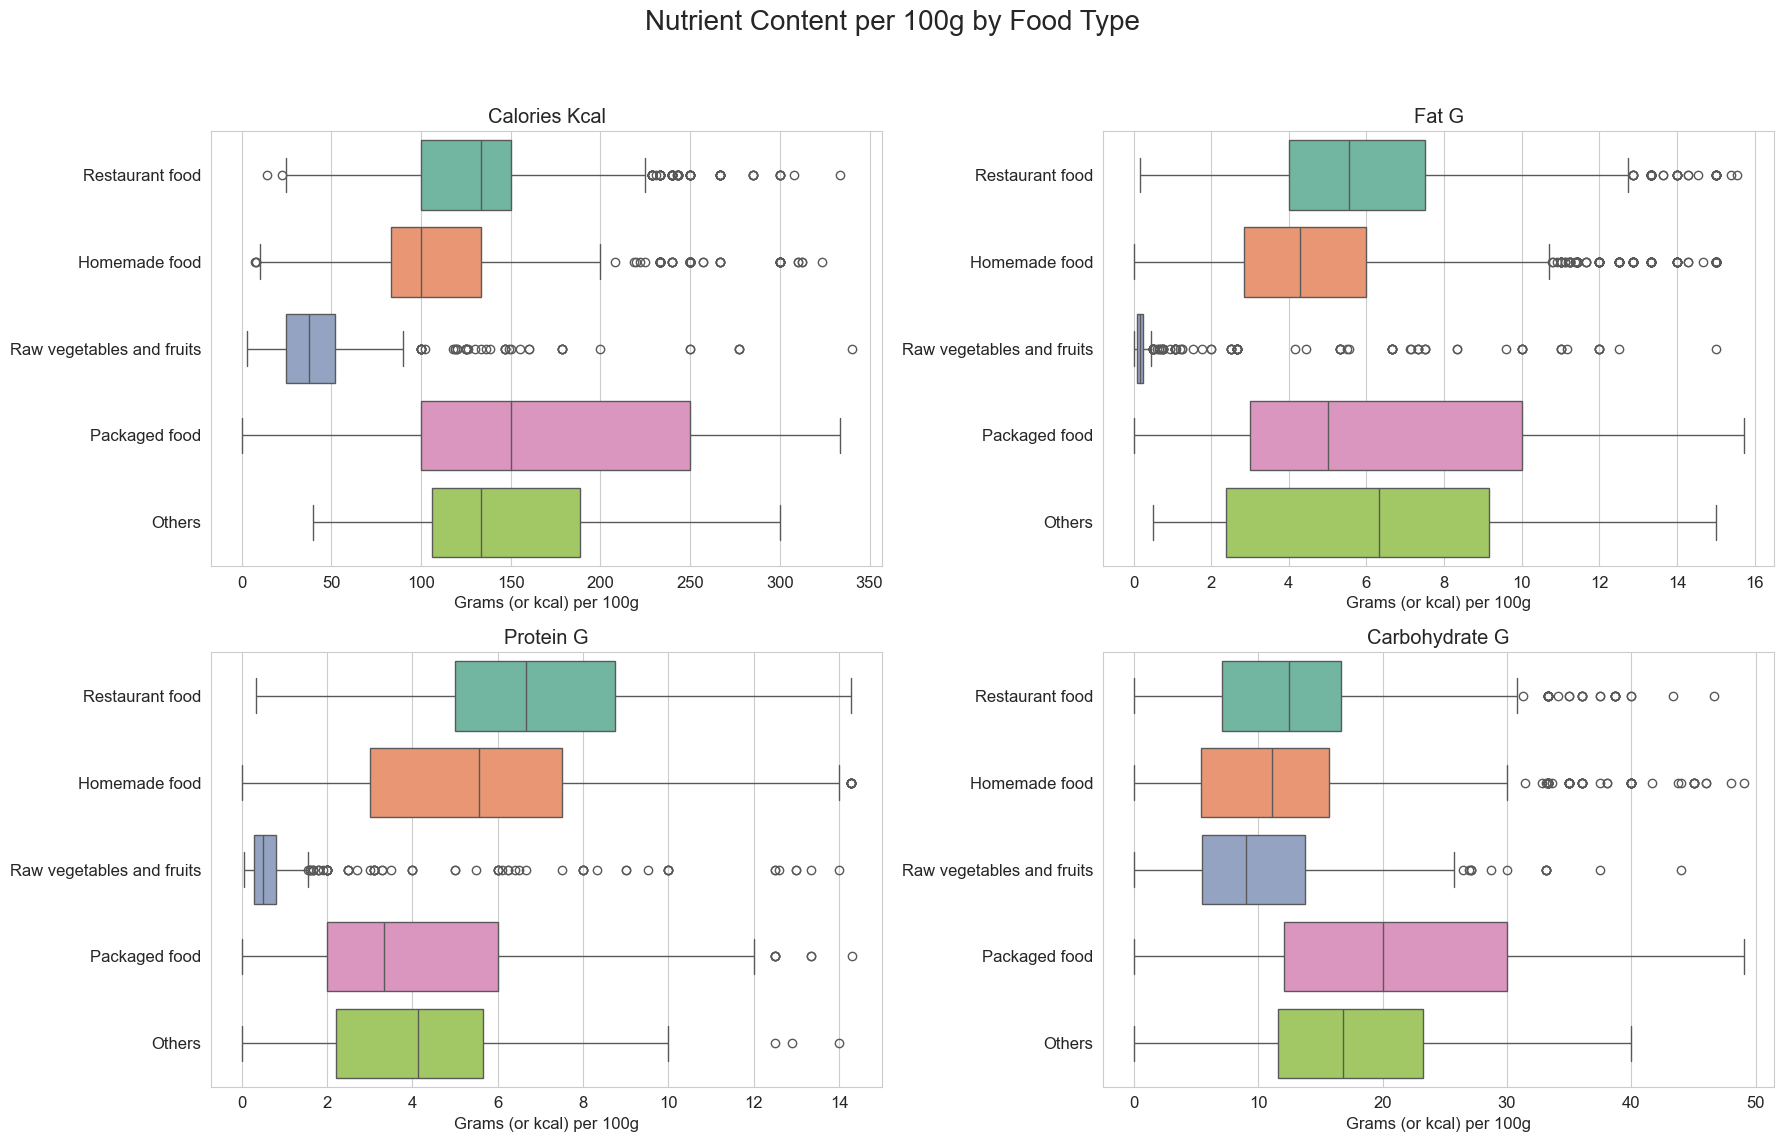


--- Top 10 Foods by Nutrient Density (Corrected) ---

Top 10 Most Calorie-Dense Foods:


,dish_name,food_type,calories_kcal_per_100g
1630,iced coffee,Packaged food,2500.0
5246,iced coffee,Packaged food,2000.0
2142,coffee with milk,Homemade food,1500.0
5314,iced coffee,Restaurant food,1500.0
10078,iced coffee,Packaged food,1500.0
346,latte with dried fruit,Restaurant food,1500.0
3627,coffee with milk,Homemade food,1500.0
721,iced coffee,Restaurant food,1500.0
8038,iced coffee,Packaged food,1500.0
5219,fruit smoothie,Homemade food,1500.0



Top 10 Highest-Protein Foods:


,dish_name,food_type,protein_g_per_100g
1630,iced coffee,Packaged food,50.000000
10832,protein powder,Packaged food,44.000000
4816,soy milk powder,Packaged food,40.000000
5246,iced coffee,Packaged food,40.000000
346,latte with dried fruit,Restaurant food,40.000000
4595,pizza,Restaurant food,33.333333
2142,coffee with milk,Homemade food,30.000000
8038,iced coffee,Packaged food,30.000000
3627,coffee with milk,Homemade food,30.000000
5190,iced coffee,Homemade food,30.000000


In [4]:
print("─" * 80)
print("▶ [STEP 4] Deep Dive into Nutrient Profiles...")
print("─" * 80)

per_100g_cols = [
    'calories_kcal_per_100g', 'fat_g_per_100g', 
    'protein_g_per_100g', 'carbohydrate_g_per_100g'
]

# --- FIX: Replace infinite values with NaN (Not a Number) ---
# This happens when total_grams is 0 but a nutrient value is present.
# np.nan is the standard way to handle missing/invalid data in pandas.
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print("Cleaned up infinite values that resulted from division by zero.\n")


# --- Distribution Histograms ---
print("\n--- Distribution of Standardized Nutrients (per 100g) ---")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle('Distribution of Nutrients (per 100g)', fontsize=20)

for i, col in enumerate(per_100g_cols):
    # Drop NaN values for plotting and cap outliers for better visualization
    q_high = df[col].dropna().quantile(0.99) 
    data_to_plot = df[(df[col] < q_high) & (df[col].notna())][col]
    sns.histplot(data_to_plot, kde=True, ax=axes[i], bins=50, color=sns.color_palette('viridis', 4)[i])
    axes[i].set_title(col.replace('_per_100g', '').replace('_', ' ').title())
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# --- Correlation Heatmap ---
print("\n--- Nutrient Correlation Heatmap (per 100g) ---")
corr = df[per_100g_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Nutrients per 100g', fontsize=16)
plt.show()

# --- Boxplots of Nutrients by Food Type ---
print("\n--- Comparing Nutrient Profiles Across Different Food Types ---")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()
fig.suptitle('Nutrient Content per 100g by Food Type', fontsize=20)

for i, col in enumerate(per_100g_cols):
    q_high = df[col].quantile(0.99)
    df_capped = df[df[col] < q_high]
    sns.boxplot(x=col, y='food_type', data=df_capped, ax=axes[i], palette='Set2')
    axes[i].set_title(col.replace('_per_100g', '').replace('_', ' ').title())
    axes[i].set_xlabel('Grams (or kcal) per 100g')
    axes[i].set_ylabel('')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Identifying High-Nutrient Foods (Now with correct results) ---
print("\n--- Top 10 Foods by Nutrient Density (Corrected) ---")
from IPython.display import display
print("\nTop 10 Most Calorie-Dense Foods:")
display(df.sort_values('calories_kcal_per_100g', ascending=False)[['dish_name', 'food_type', 'calories_kcal_per_100g']].head(10))

print("\nTop 10 Highest-Protein Foods:")
display(df.sort_values('protein_g_per_100g', ascending=False)[['dish_name', 'food_type', 'protein_g_per_100g']].head(10))


────────────────────────────────────────────────────────────────────────────────
▶ [STEP 5] Deep Dive into Ingredients...
────────────────────────────────────────────────────────────────────────────────

Word Cloud of All Ingredients:


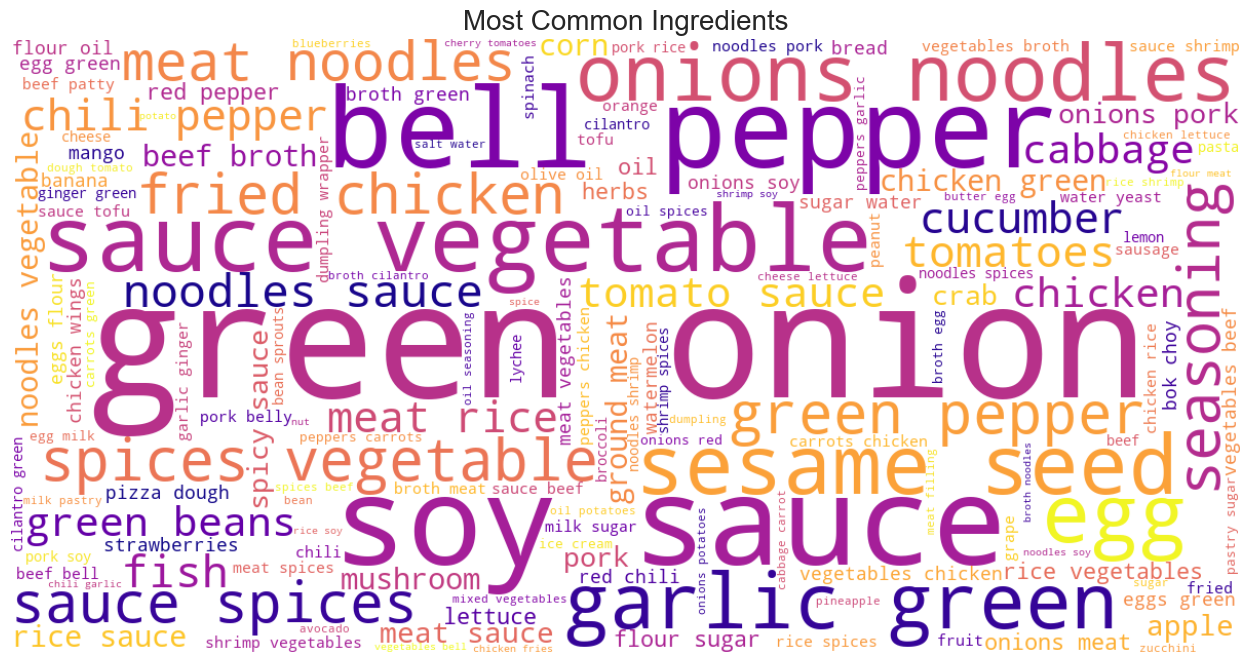


Top 20 Most Frequent Ingredients:


C:\Users\Neelanjan Dutta\AppData\Local\Temp\ipykernel_24740\655995427.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Ingredient', data=top_20_df, palette='viridis_r')


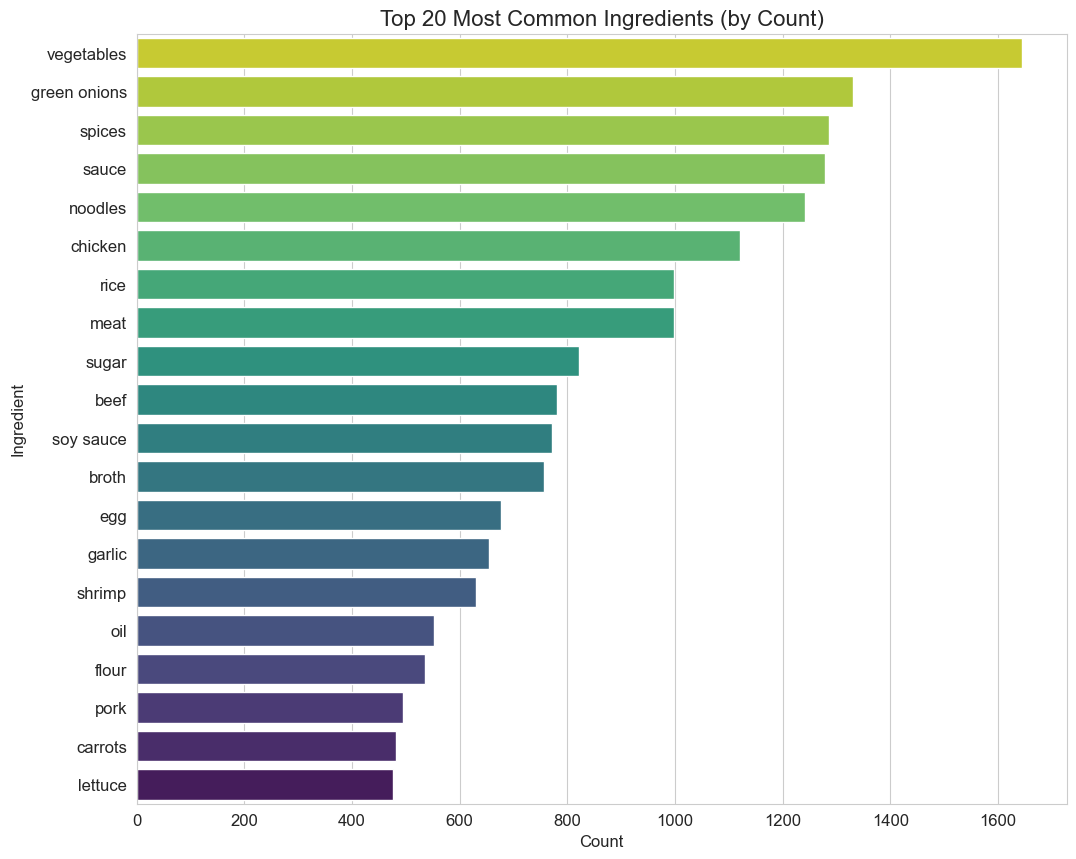

In [5]:
print("─" * 80)
print("▶ [STEP 5] Deep Dive into Ingredients...")
print("─" * 80)

# Flatten the list of lists into a single list of all ingredients
all_ingredients = [ingredient for sublist in df['ingredients'] for ingredient in sublist if ingredient]

# --- Word Cloud Visualization ---
print("\nWord Cloud of All Ingredients:")
# Note: You may need to install wordcloud: pip install wordcloud
try:
    wordcloud = WordCloud(width=1200, height=600, background_color='white', colormap='plasma', max_words=150).generate(' '.join(all_ingredients))
    plt.figure(figsize=(16, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Most Common Ingredients', fontsize=20)
    plt.show()
except ImportError:
    print("WordCloud library not found. Please install it (`pip install wordcloud`) to see the word cloud visualization.")


# --- Top 20 Ingredients Bar Chart ---
print("\nTop 20 Most Frequent Ingredients:")
ingredient_counts = Counter(all_ingredients)
top_20_df = pd.DataFrame(ingredient_counts.most_common(20), columns=['Ingredient', 'Count'])

plt.figure(figsize=(12, 10))
sns.barplot(x='Count', y='Ingredient', data=top_20_df, palette='viridis_r')
plt.title('Top 20 Most Common Ingredients (by Count)', fontsize=16)
plt.xlabel('Count')
plt.ylabel('Ingredient')
plt.show()